# Import Libraries

## Objective

Import the required libraries for data manipulation, visualization, preprocessing, dimensionality reduction, and DBSCAN clustering.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [7]:
data=pd.read_csv(r"C:\Users\anujb\Downloads\archive mall\Mall_Customers.csv")
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Remove CustomerID

CustomerID is a unique identifier and does not contribute to customer similarity.

Therefore, it is removed before clustering.

In [9]:
data=data.drop("CustomerID",axis=1)
data.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Interpretation

- The Gender feature was converted from categorical values to numerical values using Label Encoding.

In [11]:
encoder=LabelEncoder()
data["Genre"]=encoder.fit_transform(data["Genre"])
data.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


# Feature Scaling

DBSCAN is a distance-based clustering algorithm.

Features such as Age, Annual Income, and Spending Score have different scales. Standardization ensures that each feature contributes equally to the distance calculation.

In [20]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(data)
X_scaled=pd.DataFrame(
    X_scaled,
    columns=data.columns
)
X_scaled.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


# Finding the Optimal eps Value

## Objective

Unlike K-Means and Hierarchical Clustering, DBSCAN does not require the number of clusters as input.

Instead, it requires two parameters:

- **eps (ε):** Radius used to search for neighboring points.
- **min_samples:** Minimum number of neighboring points required to form a dense region.

A k-distance graph helps determine a suitable value for `eps`. The optimal `eps` is usually chosen near the "elbow" point of the graph.

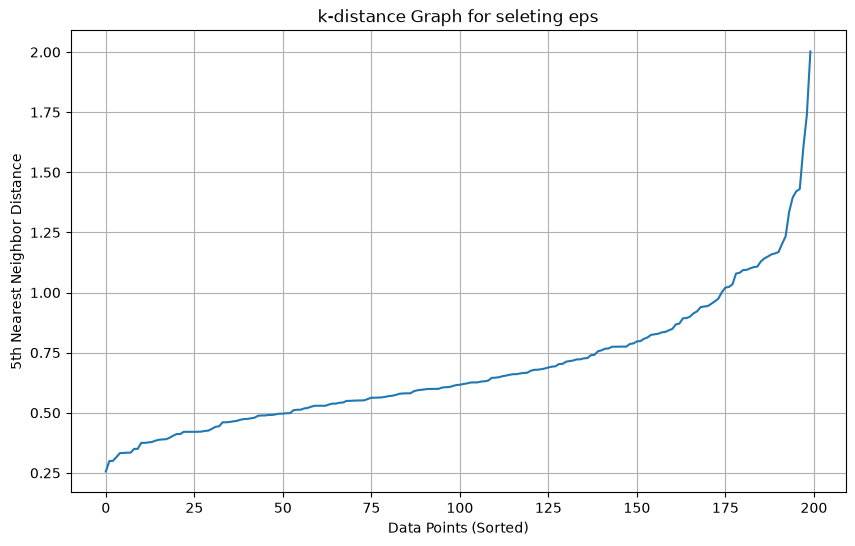

In [27]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

#Choosing min_samples=5
neighbors=NearestNeighbors(n_neighbors=5)
neighbors_fit=neighbors.fit(X_scaled)
distances,indices=neighbors_fit.kneighbors(X_scaled)

#sort distances
distances=np.sort(distances[:,4])
plt.figure(figsize=(10,6))
plt.plot(distances)

plt.xlabel("Data Points (Sorted)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("k-distance Graph for seleting eps")

plt.grid(True)
plt.show()

# Selecting DBSCAN Parameters

## Choosing `min_samples`

The dataset contains **4 features** after preprocessing:

- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

A common rule of thumb is:

> **min_samples = Number of Features + 1**

Since there are **4 features**, we selected:

- **min_samples = 5**

This value ensures that a point must have at least **5 neighboring points** within the specified radius (`eps`) to be considered a **Core Point**.

---

## Choosing `eps`

The optimal value of `eps` was determined using the **k-distance graph**.

The graph plots the distance of each point to its **5th nearest neighbor** (because `min_samples = 5`) after sorting the distances in ascending order.

The ideal `eps` is chosen at the **elbow point**, where the curve begins to increase sharply.

From the generated k-distance graph, the elbow occurred around **1.0**.

Therefore, the selected parameters were:

- **eps = 1.0**
- **min_samples = 5**

These values provide a good balance between forming meaningful clusters and correctly identifying noise points without merging distinct customer groups.

In [28]:
#Model Training For DBSCAN
from sklearn.cluster import DBSCAN

#creating DBSCAN Model
dbscan=DBSCAN(
    eps=1.0,
    min_samples=5
)

#Fit the model and predict cluster labels
clusters=dbscan.fit_predict(X_scaled)

#Add cluster labels to original dataset
data["Cluster"]=clusters

data.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,-1
1,1,21,15,81,0
2,0,20,16,6,-1
3,0,23,16,77,1
4,0,31,17,40,1


# Cluster Distribution

## Objective

Check the number of customers assigned to each cluster.

In DBSCAN:

- Cluster labels (0, 1, 2, ...) represent identified clusters.
- **-1** represents noise (outliers) that do not belong to any cluster.

In [29]:
data["Cluster"].value_counts().sort_index()

Cluster
-1     13
 0     77
 1    110
Name: count, dtype: int64

# Cluster Distribution Interpretation

## Objective

Analyze the number of customers assigned to each cluster by the DBSCAN model.

### Results

| Cluster | Number of Customers | Description |
|---------|--------------------:|-------------|
| -1 | 13 | Noise (Outliers) |
| 0 | 77 | Customer Cluster 1 |
| 1 | 110 | Customer Cluster 2 |

### Interpretation

The DBSCAN algorithm identified **two meaningful customer clusters** and **13 noise points (outliers)**.

- **Cluster 0** contains **77 customers** with similar characteristics.
- **Cluster 1** contains **110 customers** and represents the largest customer group.
- **Cluster -1** contains **13 customers** that were classified as **noise**, meaning they do not belong to any dense region. These customers may represent unusual spending behavior or unique customer profiles.

Unlike K-Means and Hierarchical Clustering, DBSCAN automatically detects outliers instead of forcing every customer into a cluster. This makes it particularly useful for identifying anomalous customer behavior and discovering naturally occurring groups based on data density.

In [32]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)
X_pca=pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)
X_pca.head()

,PC1,PC2
0,-0.406383,-0.520714
1,-1.427673,-0.367310
2,0.050761,-1.894068
3,-1.694513,-1.631908
4,-0.313108,-1.810483


# Principal Component Analysis (PCA)

## Objective

Since the dataset contains multiple features, it is difficult to visualize the clusters directly.

Principal Component Analysis (PCA) is used to reduce the dataset into **two principal components**, allowing the clusters formed by DBSCAN to be visualized in a two-dimensional space.

This step is performed only for visualization and does not affect the clustering results.

# Customer Segmentation using DBSCAN

## Objective

Visualize the customer segments identified by the DBSCAN algorithm after reducing the dataset to two dimensions using Principal Component Analysis (PCA).

This visualization helps understand:

- The separation between clusters.
- The density of customer groups.
- The noise points (outliers) detected by DBSCAN.

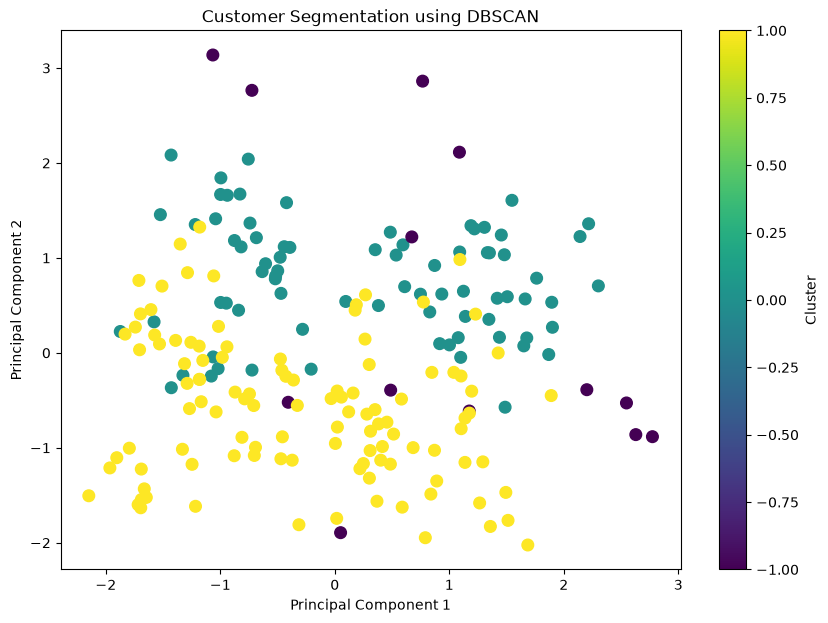

In [33]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=data["Cluster"],
    cmap="viridis",
    s=70
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using DBSCAN")

plt.colorbar(label="Cluster")

plt.show()

# Cluster Visualization Interpretation

The PCA visualization shows the customer segments identified by the DBSCAN algorithm.

- Customers with the same color belong to the same cluster.
- Points labeled **-1** represent **noise (outliers)** that do not belong to any cluster.
- DBSCAN forms clusters based on data density rather than predefined cluster centers.
- Unlike K-Means, DBSCAN can naturally identify isolated observations without forcing them into a cluster.

In [34]:
cluster_profile = data.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
})

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
-1,40.538462,62.692308,25.307692
0,39.493506,62.376623,51.610390
1,38.200000,59.036364,52.154545


# Cluster Visualization Interpretation

The scatter plot illustrates the customer segments identified by the DBSCAN algorithm after reducing the dataset into two principal components using PCA.

### Observations

- DBSCAN identified **2 dense customer clusters**.
- A total of **13 customers** were classified as **noise (Cluster -1)**.
- Noise points are isolated customers that do not belong to any dense region and may represent unusual customer behavior.
- Compared to K-Means and Hierarchical Clustering, DBSCAN does not force every customer into a cluster. Instead, it naturally detects outliers while grouping only densely connected observations.
- The clusters are reasonably separated, while the noise points are scattered around the boundaries of the clusters.

This demonstrates DBSCAN's ability to identify dense customer groups while simultaneously detecting anomalous observations.

# Cluster Profile Interpretation

The average values of Age, Annual Income, and Spending Score were calculated for each cluster to understand the characteristics of different customer groups.

| Cluster | Interpretation |
|---------|----------------|
| **Cluster 0** | Customers with moderate age, moderate annual income, and average spending behavior. These represent regular customers. |
| **Cluster 1** | Customers with slightly lower average age, moderate annual income, and similar spending behavior. This group also represents active shoppers. |
| **Cluster -1 (Noise)** | Customers identified as outliers. They have purchasing patterns that differ significantly from the main customer groups and may require individual attention or further investigation. |

### Business Insights

- The majority of customers belong to two major customer segments.
- DBSCAN successfully identified **13 unusual customers** as outliers.
- These outlier customers may represent:
  - Premium customers
  - Low-engagement customers
  - Irregular purchasing behavior
  - Customers requiring personalized marketing strategies

Unlike K-Means, DBSCAN automatically detects these exceptional customers without forcing them into existing clusters.

# My Observation on DBSCAN Results

The DBSCAN algorithm identified **2 dense customer clusters** and **13 noise (outlier) points** using the selected parameters:

- **eps = 1.0**
- **min_samples = 5**

## Analysis

The cluster profiling results show that **Cluster 0** and **Cluster 1** have very similar average values for:

- Age
- Annual Income
- Spending Score

This indicates that with **eps = 1.0**, DBSCAN merged many customers into **two broad density-based clusters** rather than creating multiple distinct customer segments.

This behavior is not incorrect. DBSCAN groups observations based on **data density**, unlike K-Means and Hierarchical Clustering, which partition all customers into a predefined number of clusters.

However, compared to:

- **K-Means (5 clusters)**
- **Hierarchical Clustering (5 clusters)**

the segmentation produced by DBSCAN is **less detailed**, making it more difficult to distinguish specific customer groups.

## Possible Improvement

To obtain more meaningful customer segments, the value of **eps** can be further tuned.

For example, experimenting with:

- `eps = 0.8`
- `eps = 0.9`

may produce:

- More well-defined clusters
- Better separation between customer groups
- Different numbers of detected outliers

Selecting the optimal **eps** is an iterative process and depends on the underlying data distribution.

# Project Conclusion

In this project, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) was applied to segment mall customers based on their demographic and spending characteristics.

The algorithm successfully identified **two dense customer clusters** and **13 outlier customers** without requiring the number of clusters as input.

Unlike K-Means and Hierarchical Clustering, DBSCAN automatically detects noise points, making it effective for identifying customers with unusual purchasing behavior.

The project also demonstrated that the choice of **eps** significantly influences the clustering results. Proper parameter tuning is essential for obtaining meaningful customer segments.

Overall, DBSCAN proved to be a powerful density-based clustering algorithm, especially for datasets containing irregular cluster shapes or potential outliers.

# Skills Demonstrated

During this project, the following skills were applied:

- Python Programming
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Label Encoding
- StandardScaler
- Principal Component Analysis (PCA)
- DBSCAN Clustering
- Density-Based Clustering
- Dendrogram Interpretation
- Hyperparameter Selection (eps & min_samples)
- Customer Segmentation
- Outlier Detection
- Cluster Profiling
- Business Insight Generation
- Data Visualization

# Key Learnings

Through this project, I learned:

- How DBSCAN clusters data based on density rather than predefined cluster centers.
- The importance of selecting appropriate values for **eps** and **min_samples**.
- How to use the **k-distance graph** to estimate the optimal eps value.
- The difference between Core Points, Border Points, and Noise Points.
- How DBSCAN automatically detects outliers.
- The importance of feature scaling for distance-based algorithms.
- How PCA helps visualize high-dimensional data.
- How to analyze customer behavior using density-based clustering.
- The strengths and limitations of DBSCAN compared with K-Means and Hierarchical Clustering.

# Future Improvements

Possible improvements for this project include:

- Experiment with different values of **eps** and **min_samples**.
- Compare DBSCAN with K-Means and Hierarchical Clustering.
- Evaluate clustering performance using:
  - Silhouette Score
  - Davies-Bouldin Index
  - Calinski-Harabasz Index
- Apply DBSCAN on larger real-world datasets.
- Explore HDBSCAN for varying density clusters.